In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle
import importlib
from scipy.stats import chisquare

import subcluster_funcs as funcs

importlib.reload(funcs)
sc._settings.settings._vector_friendly=True

import matplotlib
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Mast"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 9.52 s, sys: 1.72 s, total: 11.2 s
Wall time: 14.1 s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

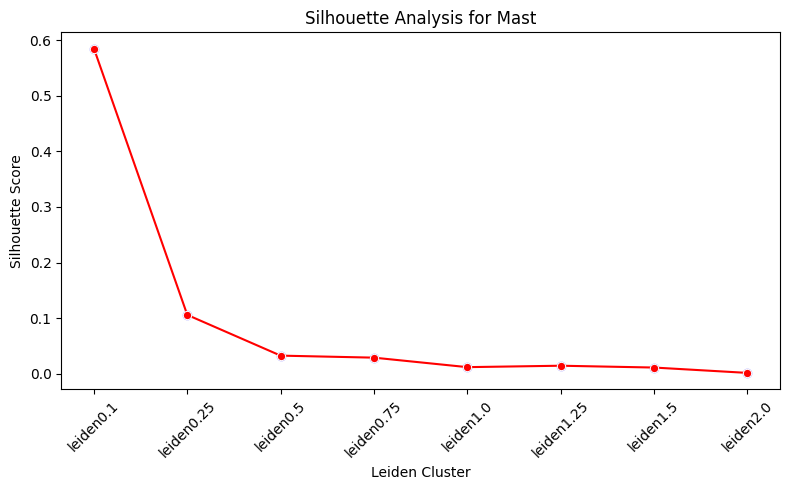

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

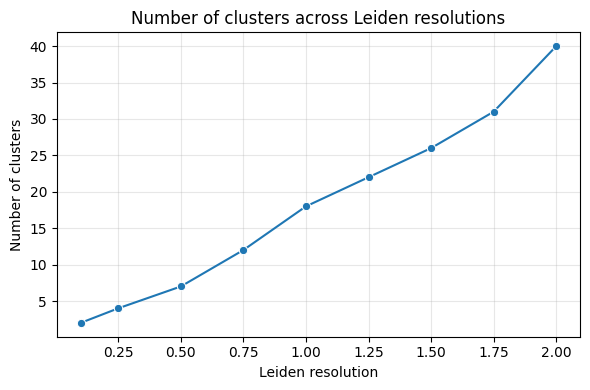

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.25

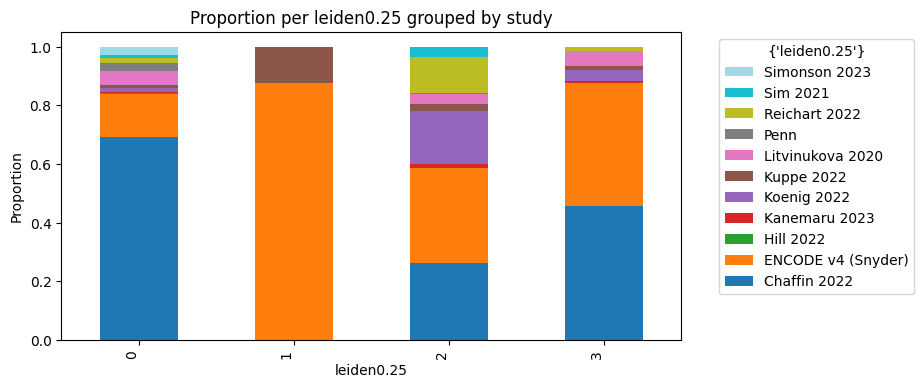

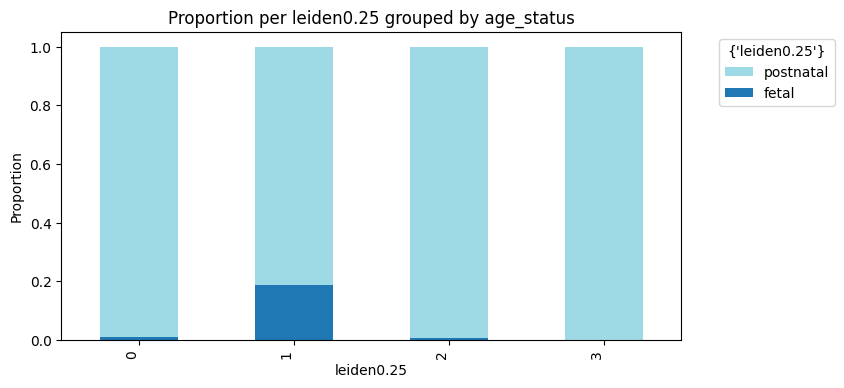

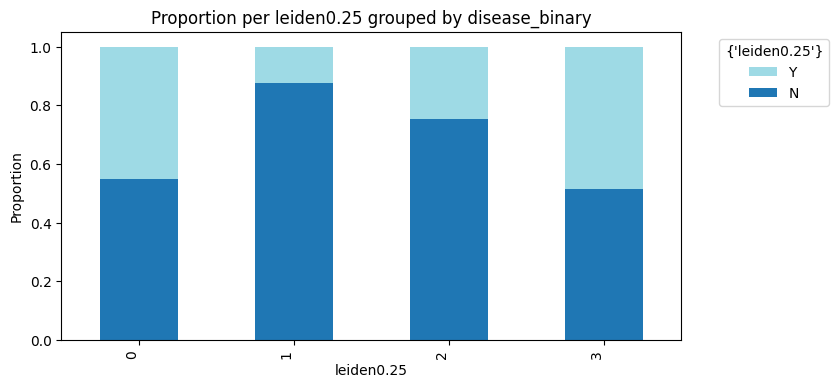

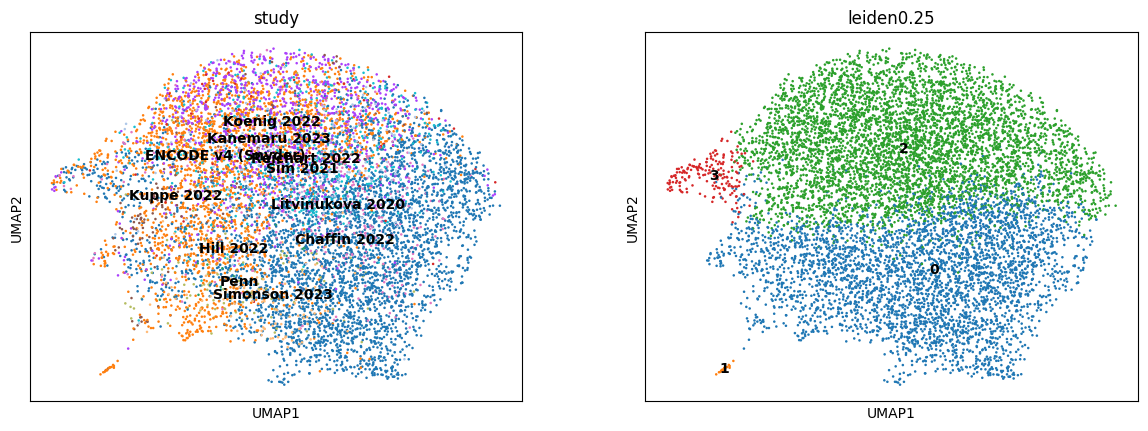

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

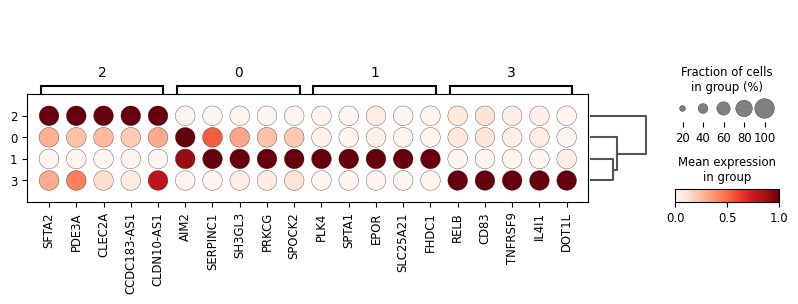

Counter({'2': 4968, '0': 3797, '3': 177, '1': 16})
CPU times: user 41.3 s, sys: 2min 45s, total: 3min 26s
Wall time: 34.2 s


['leiden0.25',
 AnnData object with n_obs × n_vars = 8958 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'le

In [7]:
%%time
leiden_key = "leiden0.25"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

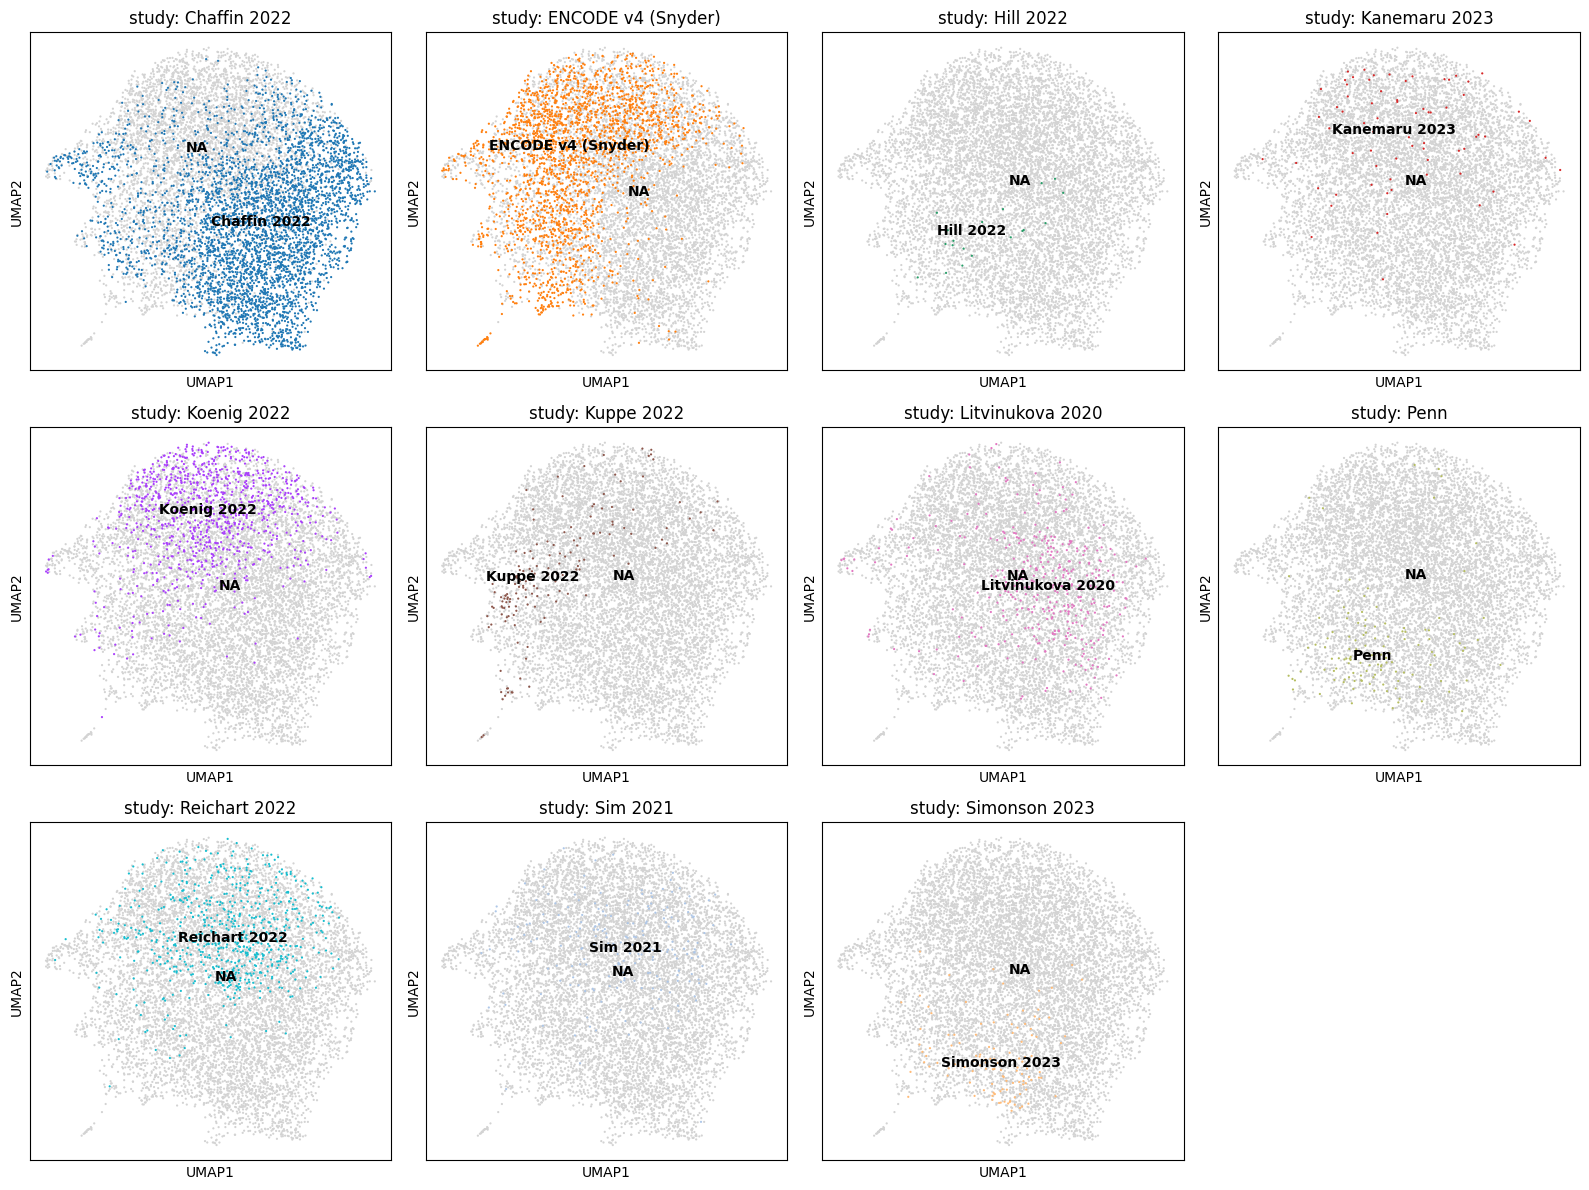

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

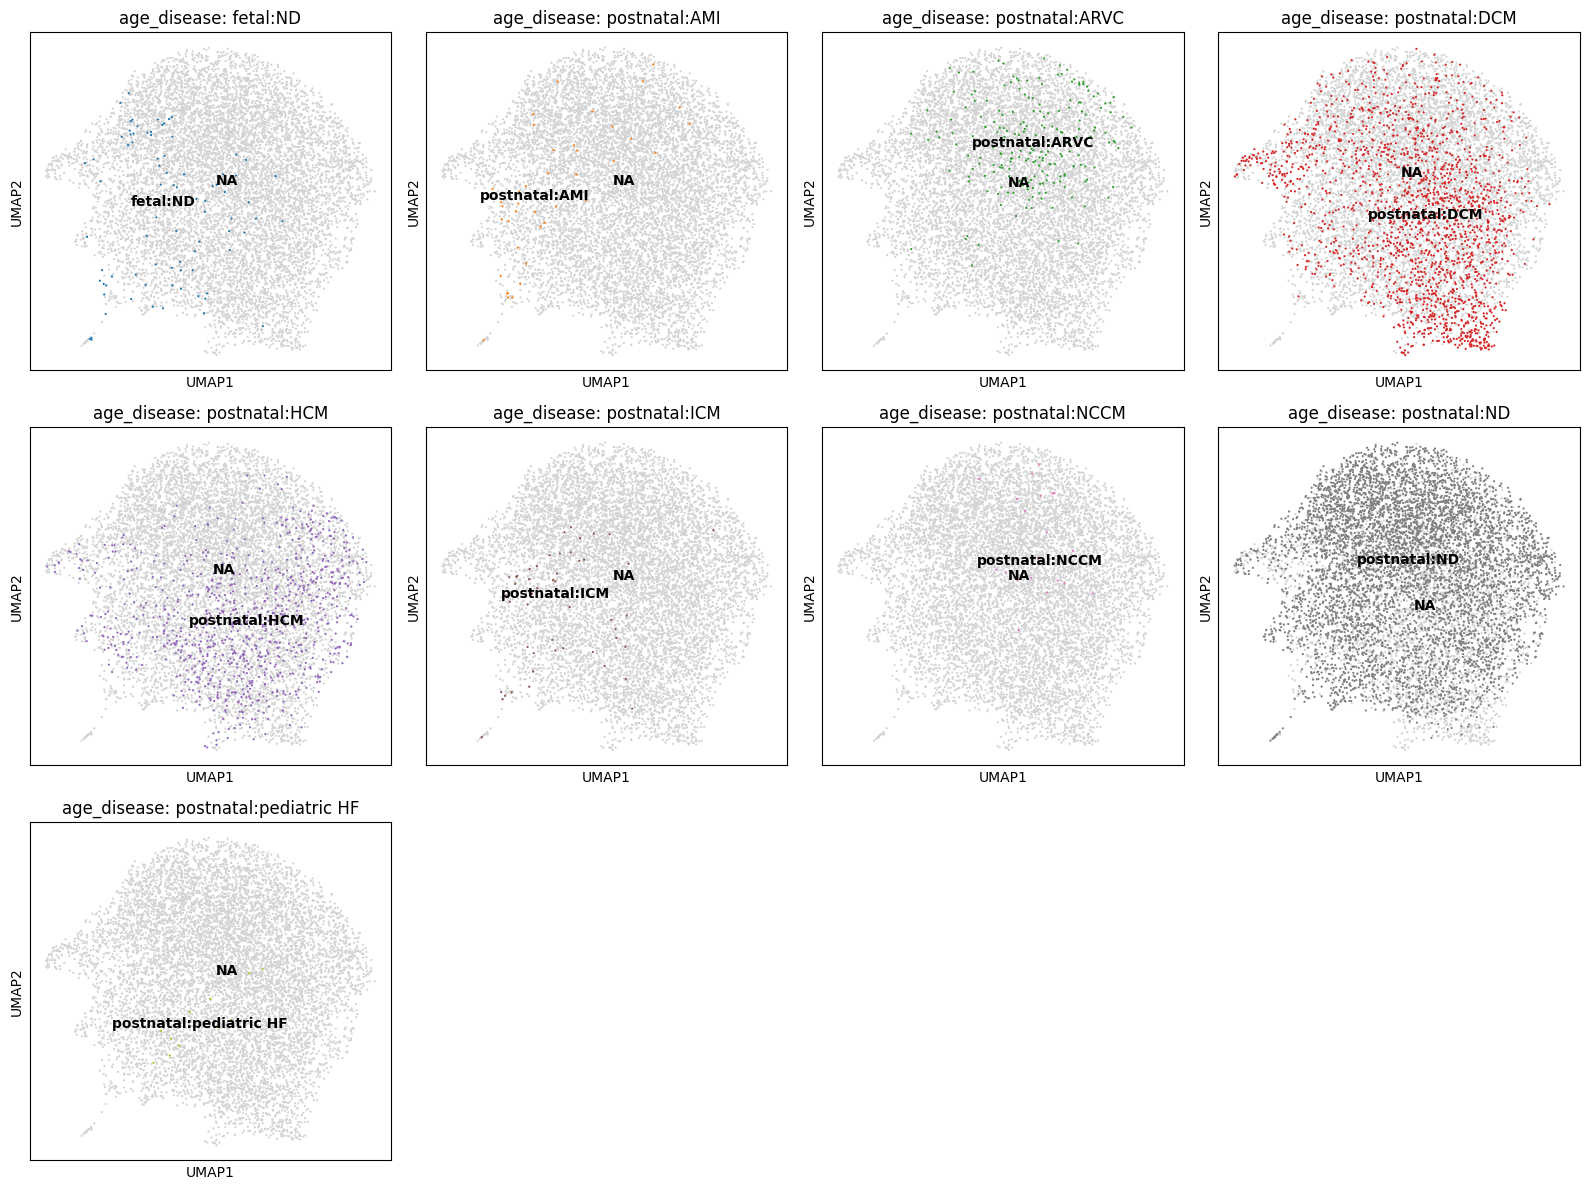

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

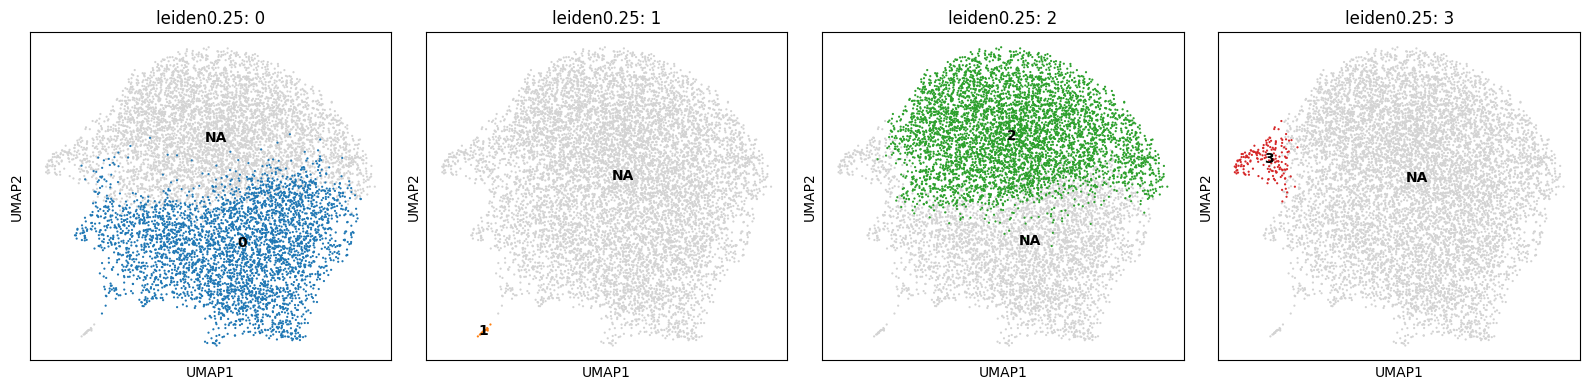

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


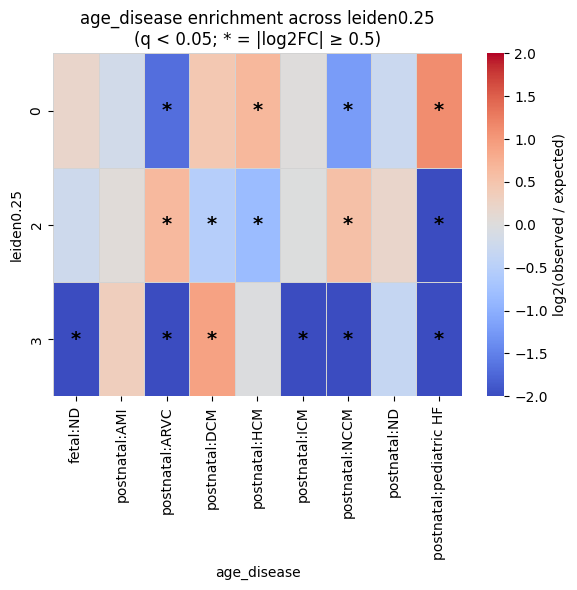

In [12]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [13]:
#sc.get.rank_genes_groups_df(adata, group="1")['names'].head(40)

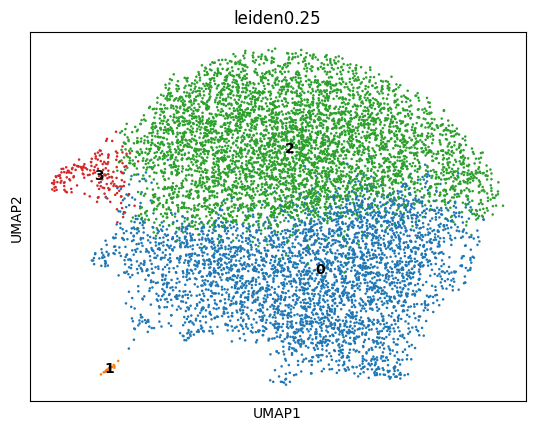

In [14]:
sc.pl.umap(adata, color = leiden_key, legend_loc = "on data")

####  Doesn't appear to be biologically heterogeneous populatins based on silhouette score; do not proceed with further subclustering or age-disease and aging enrichment analysis

### Save metadata

In [25]:
adata.obs['subcluster'] = "Mast"
palette = ["#BDBDBD"] 

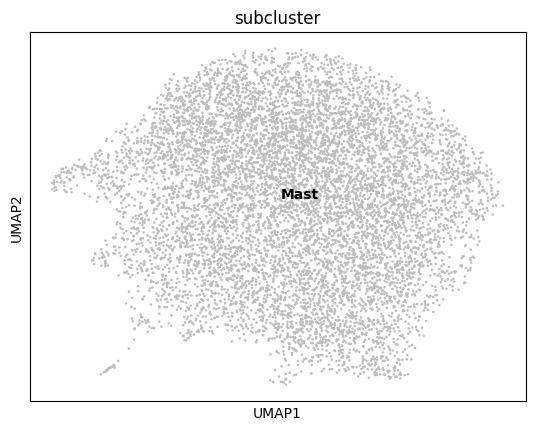

In [26]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=palette, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

In [ ]:
adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")